# Simple orthogonal model

In [29]:
include("framework.jl")
include("models_registry.jl")

In [56]:
# --- 1. Build the atomistic system ---
# Honeycomb lattice (graphene-like), 2-atom basis (A, B sublattices).
# Lattice vectors chosen so nearest-neighbor A-B distance = d0 = 1.0 Å
# to match the hopping rule in orthogonal_sk_params.toml.

d_nn = 1.0                    # nearest-neighbor A-B distance (Angstrom)
a = d_nn * sqrt(3)            # honeycomb lattice constant

lattice_vectors = [ a*sqrt(3)/2   a*sqrt(3)/2   0.0;
                     a/2          -a/2          0.0;
                     0.0           0.0          20.0 ]   # large vacuum in z

lattice = Lattice(lattice_vectors)
system = System(lattice)

add_atom!(system, :A, [0.0, 0.0, 0.0], ["s"])
add_atom!(system, :B, [d_nn, 0.0, 0.0], ["s"])

System(Lattice([1.4999999999999998 1.4999999999999998 0.0; 0.8660254037844386 -0.8660254037844386 0.0; 0.0 0.0 20.0]), Atom[Atom(:A, [0.0, 0.0, 0.0], ["s"]), Atom(:B, [1.0, 0.0, 0.0], ["s"])])

In [ ]:
# --- 2. Load the model (framework dispatches to the model layer) ---
model = load_etb(system, "orthogonal_sk", "parameters/simple_model/orthogonal_sk_params.toml")
show_params(model)

=== Orthogonal SK Model Parameters ===
Onsite energies:
  species=:A orbital=s => 0.0 eV
  species=:B orbital=s => 1.0 eV
Hopping rules (cutoff = 1.1 Å):
  :B.s <-> :B.s : t0=-2.0, d0=1.0, beta=0.0
  :A.s <-> :B.s : t0=-2.0, d0=1.0, beta=0.0
  :A.s <-> :A.s : t0=-1.0, d0=1.0, beta=0.0


In [59]:
# --- 3. Define a k-path and compute the band structure ---
b1 = [2*pi/(a*sqrt(3)),  2*pi/a, 0.0]
b2 = [2*pi/(a*sqrt(3)), -2*pi/a, 0.0]

Gamma = [0.0, 0.0, 0.0]
M     = 0.5 .* (b1 .+ b2)
K     = (2/3) .* b1 .+ (1/3) .* b2

k_path = [Gamma, M, K, Gamma]
n_points = 300

k_distances, bands = band_structure(model, k_path, n_points)

# tick positions at each high-symmetry point along the path
seg_points = n_points ÷ (length(k_path) - 1)
tick_idxs = [1 + (i-1)*seg_points for i in 1:length(k_path)-1]
push!(tick_idxs, length(k_distances))
xticks = k_distances[tick_idxs]
xticklabels = ["Γ", "M", "K", "Γ"]

4-element Vector{String}:
 "Γ"
 "M"
 "K"
 "Γ"

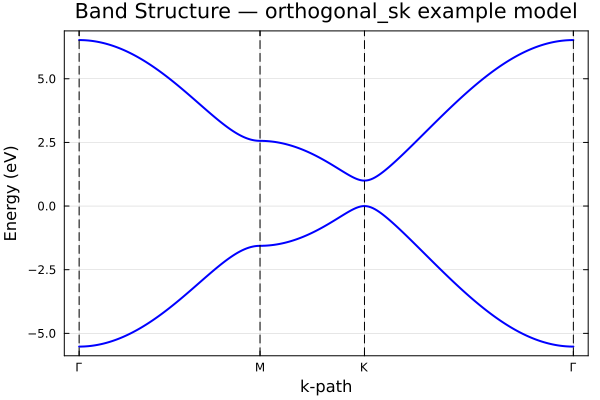

Done. Plot saved to bands_example.png


In [60]:
# --- 4. Plot ---
p = plot_bands(k_distances, bands; xticks=xticks, xticklabels=xticklabels,
               title="Band Structure — orthogonal_sk example model")
display(p)
savefig(p, "bands_example.png")

println("Done. Plot saved to bands_example.png")

# Jancu1998 model

In [18]:
include("framework.jl")
include("models_registry.jl")

In [19]:
a = 5.6
lattice_vectors = [ a/2   0.0   a/2;
                    a/2   a/2   0.0;
                    0.0   a/2   a/2]   # large vacuum in z

lattice = Lattice(lattice_vectors)
system = System(lattice)

add_atom!(system, :Si, [0.0, 0.0, 0.0], ["s","p","d","sstar"])
add_atom!(system, :Si, [a/4, a/4, a/4], ["s","p","d","sstar"])

System(Lattice([2.8 0.0 2.8; 2.8 2.8 0.0; 0.0 2.8 2.8]), Atom[Atom(:Si, [0.0, 0.0, 0.0], ["s", "p", "d", "sstar"]), Atom(:Si, [1.4, 1.4, 1.4], ["s", "p", "d", "sstar"])])

In [20]:
model = load_etb(system, "jancu1998", "parameters/jancu1998/jancu1998_Si.toml")
show_params(model)

=== Jancu 1998 spds* Model Parameters ===
Lattice constant a = 5.43 Å, cutoff = 2.6 Å
Onsite (a): Es=-2.0196 Ep=4.5448 Ed=14.1836 Es*=19.6748 Δ/3=0.0195
Onsite (c): Es=-2.0196 Ep=4.5448 Ed=14.1836 Es*=19.6748 Δ/3=0.0195
Two-center integrals (a->c):
  sss = -1.9413
  sps = 2.7836
  pss = 2.7836
  sSss = -1.6933
  sssS = -1.6933
  sSsSs = -3.3081
  sSps = 2.8428
  psSs = 2.8428
  pps = 4.1068
  ppp = -1.5934
  sds = -2.7998
  dss = -2.7998
  sSds = -0.7003
  dsSs = -0.7003
  pds = -2.1073
  dps = -2.1073
  pdp = 1.9977
  dpp = 1.9977
  dds = -1.2327
  ddp = 2.5145
  ddd = -2.4734
Number of nearest-neighbor bonds: 4


In [21]:
Γ = [0.0, 0.0, 0.0]
L = [0.5, 0.5, 0.5]
K = [0.5, 0.5, 0.0]
X = [0.0, 0.5, 0.0]

k_path = [K, L, Γ, X]
n_points = 100

k_distances, bands = band_structure(model, k_path, n_points)

# tick positions at each high-symmetry point along the path
seg_points = n_points ÷ (length(k_path) - 1)
tick_idxs = [1 + (i-1)*seg_points for i in 1:length(k_path)-1]
push!(tick_idxs, length(k_distances))
xticks = k_distances[tick_idxs]
xticklabels = ["K", "L", "Γ", "X"]

4-element Vector{String}:
 "K"
 "L"
 "Γ"
 "X"

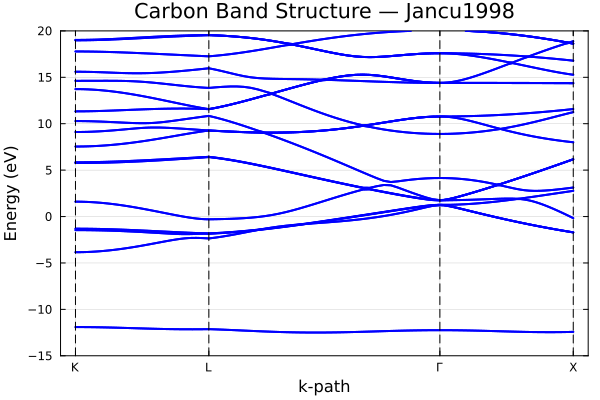

In [24]:
p = plot_bands(k_distances, bands; xticks=xticks, xticklabels=xticklabels,
               title="Carbon Band Structure — Jancu1998")
p = plot(p; ylims=(-15,20))
display(p)
#savefig(p, "bands_example.png")